# Solar Filament Segmentation Challenge 2026
## U-Net + ConvNeXt training, evaluation, and inference

This notebook is the pipeline driver: it installs the extra deep-learning
dependencies, points the shared config at Kaggle's `/kaggle/input` mounts,
then calls the same `scripts/train.py` / `scripts/evaluate.py` / `scripts/infer.py`
used locally -- so the logic lives in one place (the code dataset attached to
this kernel), not duplicated into notebook cells.

**Task**: binary, category-agnostic filament segmentation (the competition's
Overview page states class labels are out of scope for scoring). A U-Net with a
ConvNeXt-Tiny encoder predicts a foreground probability map; watershed
post-processing splits it into individual filament instances for the
Panoptic-Quality-scored submission format.

### 0. Confirm the mounted data layout
Adjust `configs/config_kaggle.yaml`'s `data:` paths if this doesn't match.

In [1]:
!git clone https://github.com/jprakash-1/Solar-Filament-Segmentation.git


Cloning into 'Solar-Filament-Segmentation'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (92/92), done.0/92)
remote: Total 123 (delta 49), reused 99 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 40.31 KiB | 5.76 MiB/s, done.
Resolving deltas: 100% (49/49), done.


In [2]:
%cd /kaggle/working/Solar-Filament-Segmentation
!ls

/kaggle/working/Solar-Filament-Segmentation
configs  kaggle_notebook  outputs    requirements.txt  src
data	 kaggle_package   README.md  scripts


In [3]:
!find /kaggle/input -maxdepth 3

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/filament-segmentation-2026
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026


### 1. Bring in the code dataset and install missing dependencies

In [4]:
!git pull origin master 

From https://github.com/jprakash-1/Solar-Filament-Segmentation
 * branch            master     -> FETCH_HEAD
Already up to date.


In [5]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 903.2 kB/s eta 0:00:000:01


In [6]:
import torch
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))

torch 2.10.0+cu128
cuda available: True
device: Tesla T4


### 2. Train
`configs/config_kaggle.yaml` sets `image_size: 2048` (native resolution) and a GPU-sized
`batch_size` (default 4 -- raise/lower depending on VRAM). Override any config value
from the CLI, e.g. `--epochs` / `--batch-size`, without editing the file.

In [7]:
!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") \
    scripts/train.py --config configs/config_kaggle.yaml

W0821 15:20:49.189000 112 torch/distributed/run.py:852] 
W0821 15:20:49.189000 112 torch/distributed/run.py:852] *****************************************
W0821 15:20:49.189000 112 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0821 15:20:49.189000 112 torch/distributed/run.py:852] *****************************************
Using device: cuda:0 (DDP, world_size=2)
train images: 1039  val images: 115
model.safetensors: 100%|█████████████████████| 114M/114M [00:02<00:00, 46.7MB/s]
epoch 1/40 [train]:   0%|                                | 0/86 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Grad strides do not match bucket view strides. This may indicate grad was not created according to the gradient layout contract, or that the param's strides chan

### 3. Training curve

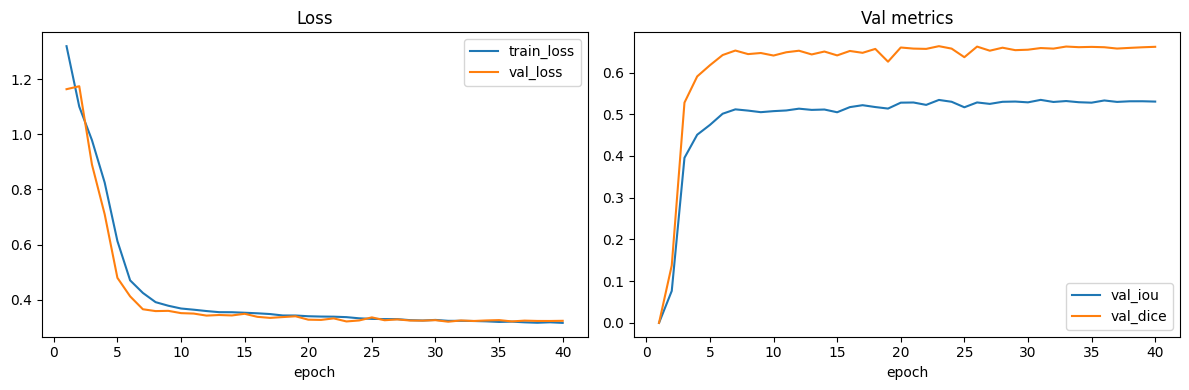

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv('outputs/logs/train_log.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log['epoch'], log['train_loss'], label='train_loss')
axes[0].plot(log['epoch'], log['val_loss'], label='val_loss')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('Loss')
axes[1].plot(log['epoch'], log['val_iou'], label='val_iou')
axes[1].plot(log['epoch'], log['val_dice_torchmetrics'], label='val_dice')
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].set_title('Val metrics')
fig.tight_layout()
plt.show()

### 4. Evaluate (instance-level Panoptic Quality + Dice)
Runs the full inference + post-processing pipeline against the held-out val split's
ground truth -- the same instance-splitting logic used for the actual submission --
as a local sanity check against the competition's real leaderboard metric.

In [9]:
!python scripts/evaluate.py --checkpoint outputs/checkpoints/best.pt

Using device: cuda
Evaluating on 115 val images (checkpoint epoch 23)
evaluate: 100%|███████████████████████████████| 115/115 [04:20<00:00,  2.26s/it]

mean Dice (semantic):  0.6749
mean IoU  (semantic):  0.5243
mean Panoptic Quality: 0.0318  (IoU thresh=0.5)


### 5. Inference -> submission CSV
Predicts on the test set, splits into filament instances, RLE-encodes each one, and
writes `outputs/submissions/submission_<timestamp>.csv` in the exact
`filament_id,segmentation_rle` format the competition expects.

In [10]:
!python scripts/infer.py --checkpoint outputs/checkpoints/best.pt --visualize 10

Using device: cuda
Running inference on 180 test images
infer: 100%|██████████████████████████████████| 180/180 [04:41<00:00,  1.57s/it]
Wrote 6548 filament rows for 180 images to outputs/submissions/submission_20260821_160655.csv
Saved visualizations to outputs/eda/predictions


In [11]:
import glob
import pandas as pd

submissions = sorted(glob.glob('outputs/submissions/*.csv'))
print('Latest submission:', submissions[-1] if submissions else 'none found')
pd.read_csv(submissions[-1]).head()

Latest submission: outputs/submissions/submission_20260821_160655.csv


,filament_id,segmentation_rle
0,20110120105534Ch_1,d`di24ko11O2N2M2O2N2N101O1O010O10O1O1O01000O00...
1,20110120105534Ch_2,o`Xk28`o1:O0O1000000O2N01O10O1O0010O001O1O001O...
2,20110120105534Ch_3,ca^P33mo11N2O01O01O1O0001O00001O000000001N100N...
3,20110120105534Ch_4,ca^m25jo12J6O0010O1000O000010O1000O00000001O00...
4,20110120105534Ch_5,eahn2;eo10000000000000000O100O100O2O0N2O[^UP1


### 6. Spot-check a few predictions

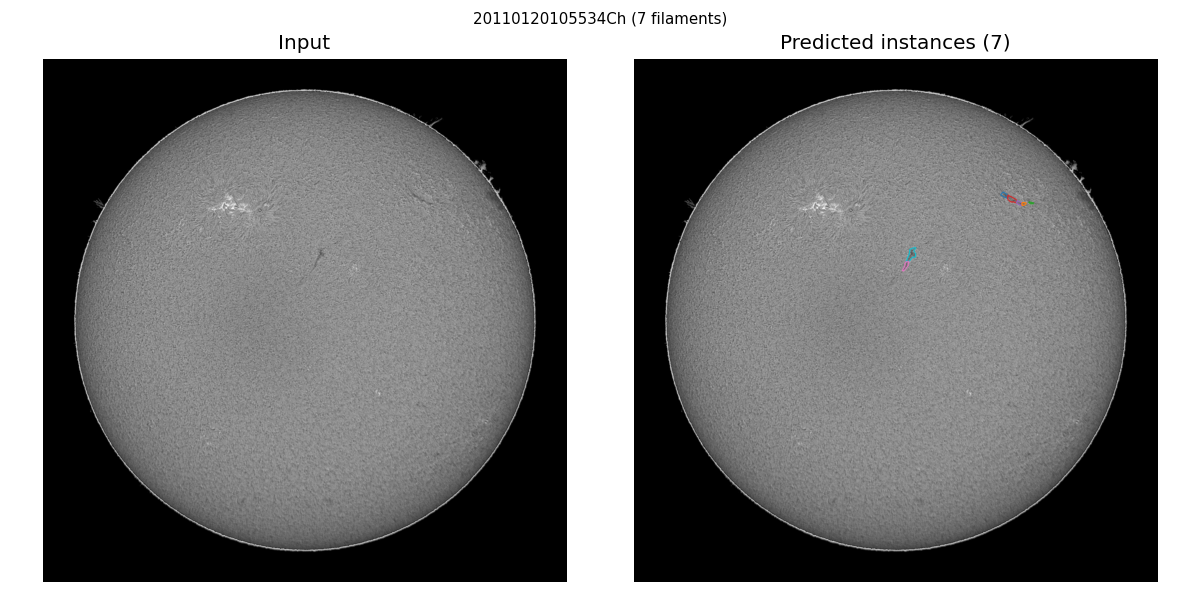

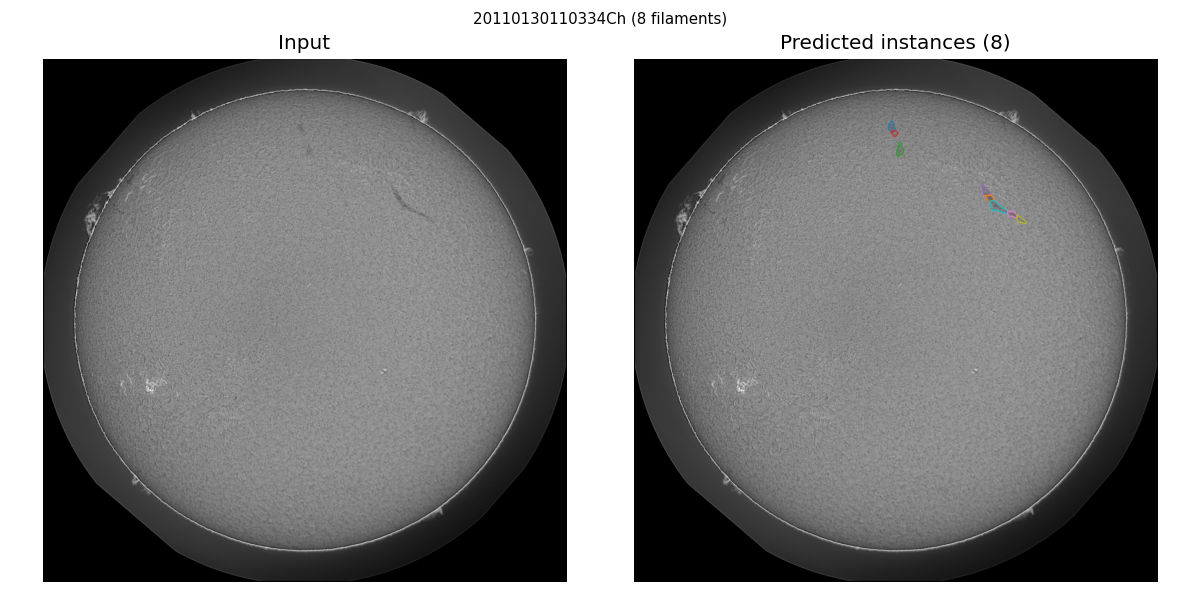

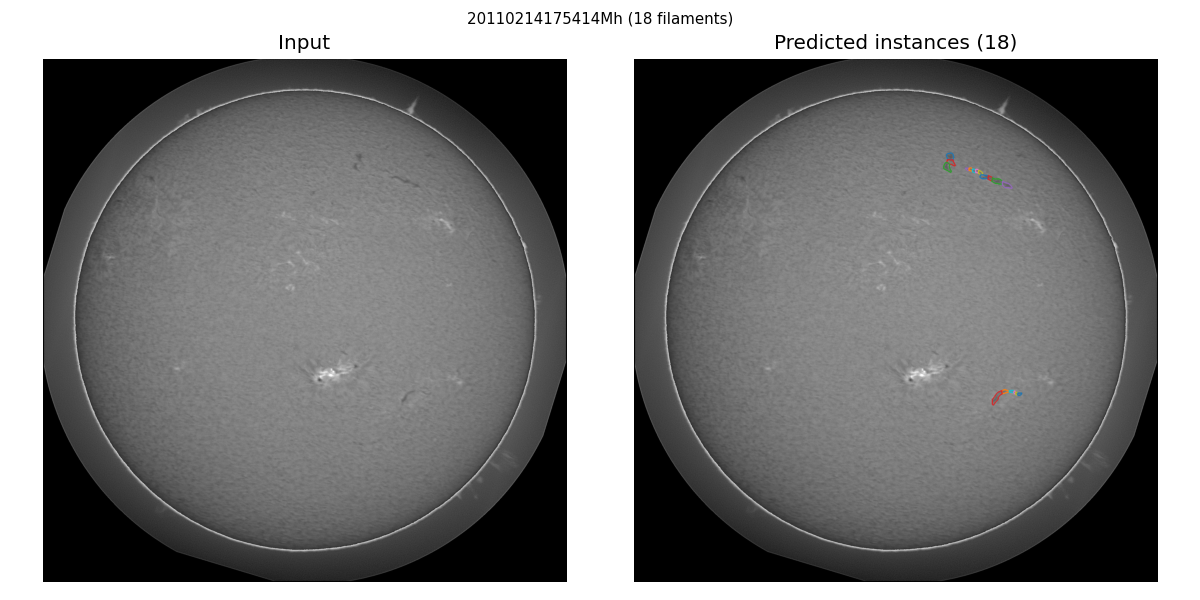

In [12]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/eda/predictions/*.png'))[:3]:
    display(Image.open(path))

### Outputs
- `outputs/checkpoints/best.pt` / `last.pt` -- model weights
- `outputs/logs/train_log.csv` -- per-epoch metrics
- `outputs/submissions/submission_*.csv` -- ready to submit to the competition
- `outputs/eda/predictions/*.png` -- qualitative overlays

All of the above persist as this notebook's **Output** after a committed run,
downloadable via `kaggle kernels output <username>/filament-unet-convnext-training -p <local-dir>`.

In [13]:
!ls

configs  kaggle_notebook  outputs    requirements.txt  src
data	 kaggle_package   README.md  scripts


In [22]:
%cd ..

/kaggle/working/Solar-Filament-Segmentation


In [20]:
!zip -r  checkpoints.zip checkpoints

  adding: checkpoints/ (stored 0%)
  adding: checkpoints/.gitkeep (stored 0%)
  adding: checkpoints/best.pt (deflated 7%)
  adding: checkpoints/last.pt (deflated 7%)


In [23]:
!zip -r outputs.zip outputs/

  adding: outputs/ (stored 0%)
  adding: outputs/checkpoints.zip (stored 0%)
  adding: outputs/logs/ (stored 0%)
  adding: outputs/logs/.gitkeep (stored 0%)
  adding: outputs/logs/train_log.csv (deflated 51%)
  adding: outputs/eda/ (stored 0%)
  adding: outputs/eda/predictions/ (stored 0%)
  adding: outputs/eda/predictions/20110130110334Ch_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110329082654Uh_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110529063154Uh_pred.png (deflated 5%)
  adding: outputs/eda/predictions/20110424064534Lh_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110531070514Th_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110603123034Ch_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110408083214Th_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110429120534Ch_pred.png (deflated 4%)
  adding: outputs/eda/predictions/20110120105534Ch_pred.png (deflated 5%)
  adding: outputs/eda/predictions/201102141